# Bank Loan Status Prediction
## การพยากรณ์สถานะการชำระหนี้ของลูกค้าธนาคาร

---

### Background & Motivation

ในอุตสาหกรรมการเงิน การประเมินความเสี่ยงด้านสินเชื่อ (Credit Risk Assessment) เป็นหนึ่งในงานที่สำคัญที่สุด ธนาคารและสถาบันการเงินต้องตัดสินใจอยู่ตลอดเวลาว่าจะปล่อยสินเชื่อให้ลูกค้ารายใด และลูกค้ารายใดมีโอกาสที่จะ **ผิดนัดชำระหนี้ (Charged Off)** สูง

Project นี้มีจุดเริ่มต้นจากคำถามทาง Business ที่ว่า:
> **"เราจะสามารถคาดการณ์ได้หรือไม่ว่าลูกค้ารายใดจะชำระหนี้ครบ (Fully Paid) หรือผิดนัดชำระ (Charged Off)?"**

### Approach
1. **Exploratory Data Analysis (EDA)** - สำรวจข้อมูล หา pattern และ insight
2. **Data Cleaning & Feature Engineering** - ทำความสะอาดข้อมูล สร้าง features ใหม่
3. **Modeling** - ทดลองหลาย models เปรียบเทียบประสิทธิภาพ
4. **Evaluation & Insights** - สรุปผลและ business recommendations

### Dataset
- **Training set**: ~100,000 records พร้อม label `Loan Status`
- **Test set**: ~10,000 records (ไม่มี label)
- **Features**: 19 columns ครอบคลุมข้อมูลส่วนตัว สินเชื่อ และประวัติเครดิต

---
## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load Data

In [2]:
# Load datasets
train = pd.read_csv('credit_train.csv')
test = pd.read_csv('credit_test.csv')

print(f'Training set: {train.shape[0]:,} rows, {train.shape[1]} columns')
print(f'Test set:     {test.shape[0]:,} rows, {test.shape[1]} columns')
print(f'\nTarget column (Loan Status) มีเฉพาะใน train set')

Training set: 100,514 rows, 19 columns
Test set:     10,353 rows, 18 columns

Target column (Loan Status) มีเฉพาะใน train set


In [3]:
# Preview training data
train.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [4]:
# Preview test data
test.head()

,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


---
## 3. EDA - Data Overview
สำรวจโครงสร้างข้อมูลเบื้องต้น: data types, missing values, และ basic statistics

In [5]:
# Data types and non-null counts
print('=== Training Data Info ===')
print(train.dtypes)
print(f'\nTotal rows: {len(train):,}')

=== Training Data Info ===
Loan ID                          object
Customer ID                      object
Loan Status                      object
Current Loan Amount             float64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts         float64
Number of Credit Problems       float64
Current Credit Balance          float64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

Total rows: 100,514


In [6]:
# Descriptive statistics สำหรับ numerical columns
train.describe().round(2)

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,100000.00,80846.00,8.084600e+04,100000.00,100000.00,46859.0,100000.00,100000.00,100000.00,9.999800e+04,99796.00,99990.00
mean,11760447.39,1076.46,1.378277e+06,18472.41,18.20,34.9,11.13,0.17,294637.38,7.607984e+05,0.12,0.03
std,31783942.55,1475.40,1.081360e+06,12174.99,7.02,22.0,5.01,0.48,376170.93,8.384503e+06,0.35,0.26
min,10802.00,585.00,7.662700e+04,0.00,3.60,0.0,0.00,0.00,0.00,0.000000e+00,0.00,0.00
25%,179652.00,705.00,8.488440e+05,10214.16,13.50,16.0,8.00,0.00,112670.00,2.734380e+05,0.00,0.00
50%,312246.00,724.00,1.174162e+06,16220.30,16.90,32.0,10.00,0.00,209817.00,4.678740e+05,0.00,0.00
75%,524942.00,741.00,1.650663e+06,24012.06,21.70,51.0,14.00,0.00,367958.75,7.829580e+05,0.00,0.00
max,99999999.00,7510.00,1.655574e+08,435843.28,70.50,176.0,76.00,15.00,32878968.00,1.539738e+09,7.00,15.00


In [7]:
# Descriptive statistics สำหรับ categorical columns
train.describe(include='object')

,Loan ID,Customer ID,Loan Status,Term,Years in current job,Home Ownership,Purpose
count,100000,100000,100000,100000,95778,100000,100000
unique,81999,81999,2,2,11,4,16
top,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,Short Term,10+ years,Home Mortgage,Debt Consolidation
freq,2,2,77361,72208,31121,48410,78552


In [8]:
# Unique values ในแต่ละ column
for col in train.columns:
    print(f'{col}: {train[col].nunique()} unique values')

Loan ID: 81999 unique values
Customer ID: 81999 unique values
Loan Status: 2 unique values
Current Loan Amount: 22004 unique values
Term: 2 unique values
Credit Score: 324 unique values
Annual Income: 36174 unique values
Years in current job: 11 unique values
Home Ownership: 4 unique values
Purpose: 16 unique values
Monthly Debt: 65765 unique values
Years of Credit History: 506 unique values
Months since last delinquent: 116 unique values
Number of Open Accounts: 51 unique values
Number of Credit Problems: 14 unique values
Current Credit Balance: 32730 unique values
Maximum Open Credit: 44596 unique values
Bankruptcies: 8 unique values
Tax Liens: 12 unique values


---
## 4. EDA - Target Distribution
ดูสัดส่วนของ **Fully Paid** vs **Charged Off** ว่า data มี imbalance หรือไม่

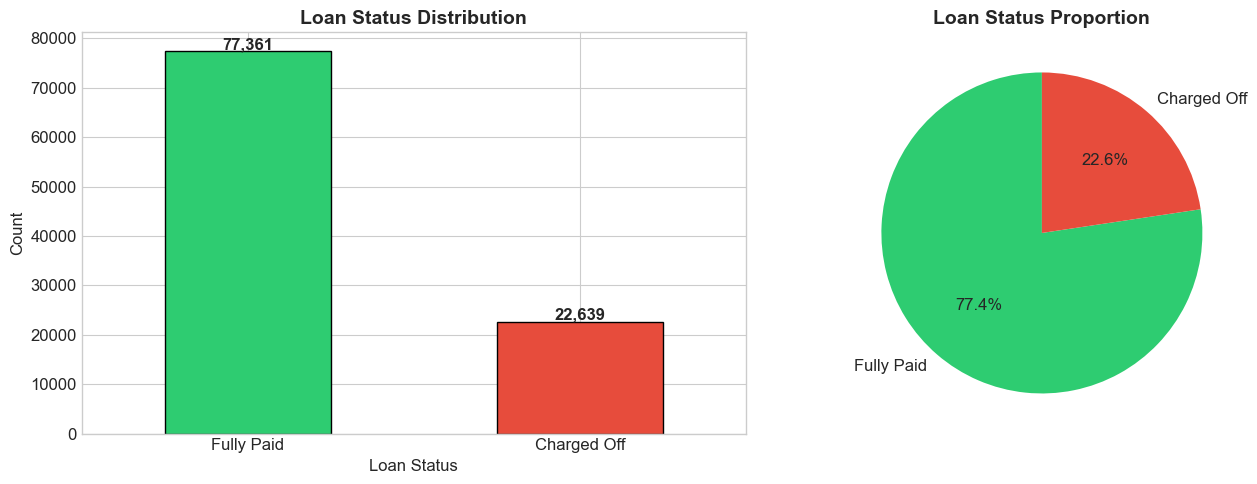


Fully Paid: 77,361 (77.0%)
Charged Off: 22,639 (22.5%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts = train['Loan Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
target_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', 
                   startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Loan Status Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('assets/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFully Paid: {target_counts.get("Fully Paid", 0):,} ({target_counts.get("Fully Paid", 0)/len(train)*100:.1f}%)')
print(f'Charged Off: {target_counts.get("Charged Off", 0):,} ({target_counts.get("Charged Off", 0)/len(train)*100:.1f}%)')

---
## 5. EDA - Missing Values Analysis
วิเคราะห์ pattern ของ missing values เพื่อวางแผนการ impute ข้อมูล

In [10]:
# Missing values summary
missing = train.isnull().sum()
missing_pct = (train.isnull().sum() / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('=== Missing Values Summary (Train) ===')
missing_df

=== Missing Values Summary (Train) ===


,Missing Count,Missing %
Months since last delinquent,53655,53.38
Credit Score,19668,19.57
Annual Income,19668,19.57
Years in current job,4736,4.71
Bankruptcies,718,0.71
Tax Liens,524,0.52
Years of Credit History,514,0.51
Maximum Open Credit,516,0.51
Current Credit Balance,514,0.51
Number of Credit Problems,514,0.51


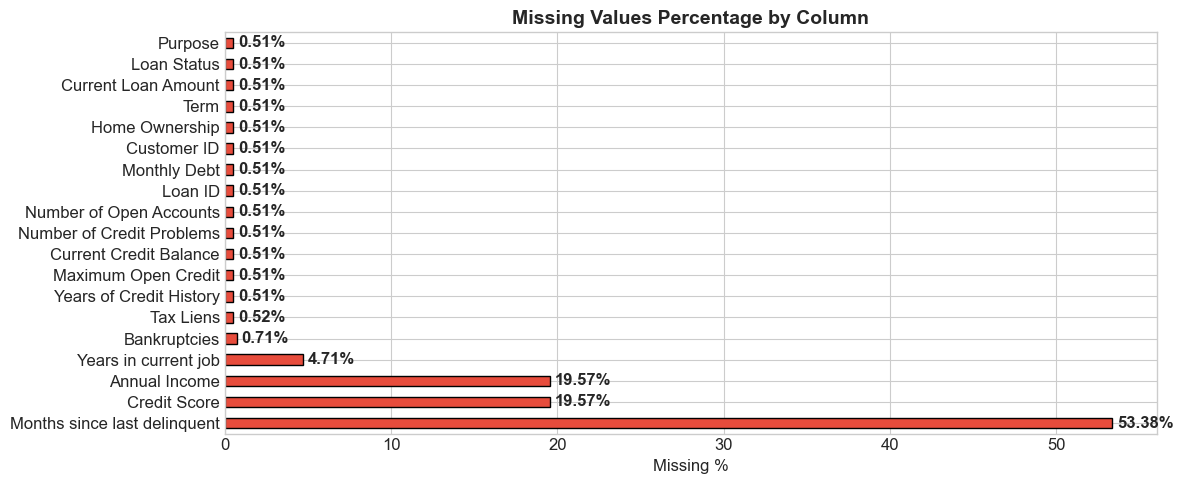

In [11]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 5))

if len(missing_df) > 0:
    missing_df['Missing %'].plot(kind='barh', color='#e74c3c', edgecolor='black', ax=ax)
    ax.set_title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing %')
    for i, v in enumerate(missing_df['Missing %']):
        ax.text(v + 0.3, i, f'{v}%', va='center', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No missing values!', ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.savefig('assets/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. EDA - Numerical Features
สำรวจ distribution ของ numerical features และความสัมพันธ์กับ target

In [12]:
# กำหนด numerical columns (exclude IDs)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numerical columns ({len(num_cols)}): {num_cols}')

Numerical columns (12): ['Current Loan Amount', 'Credit Score', 'Annual Income', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']


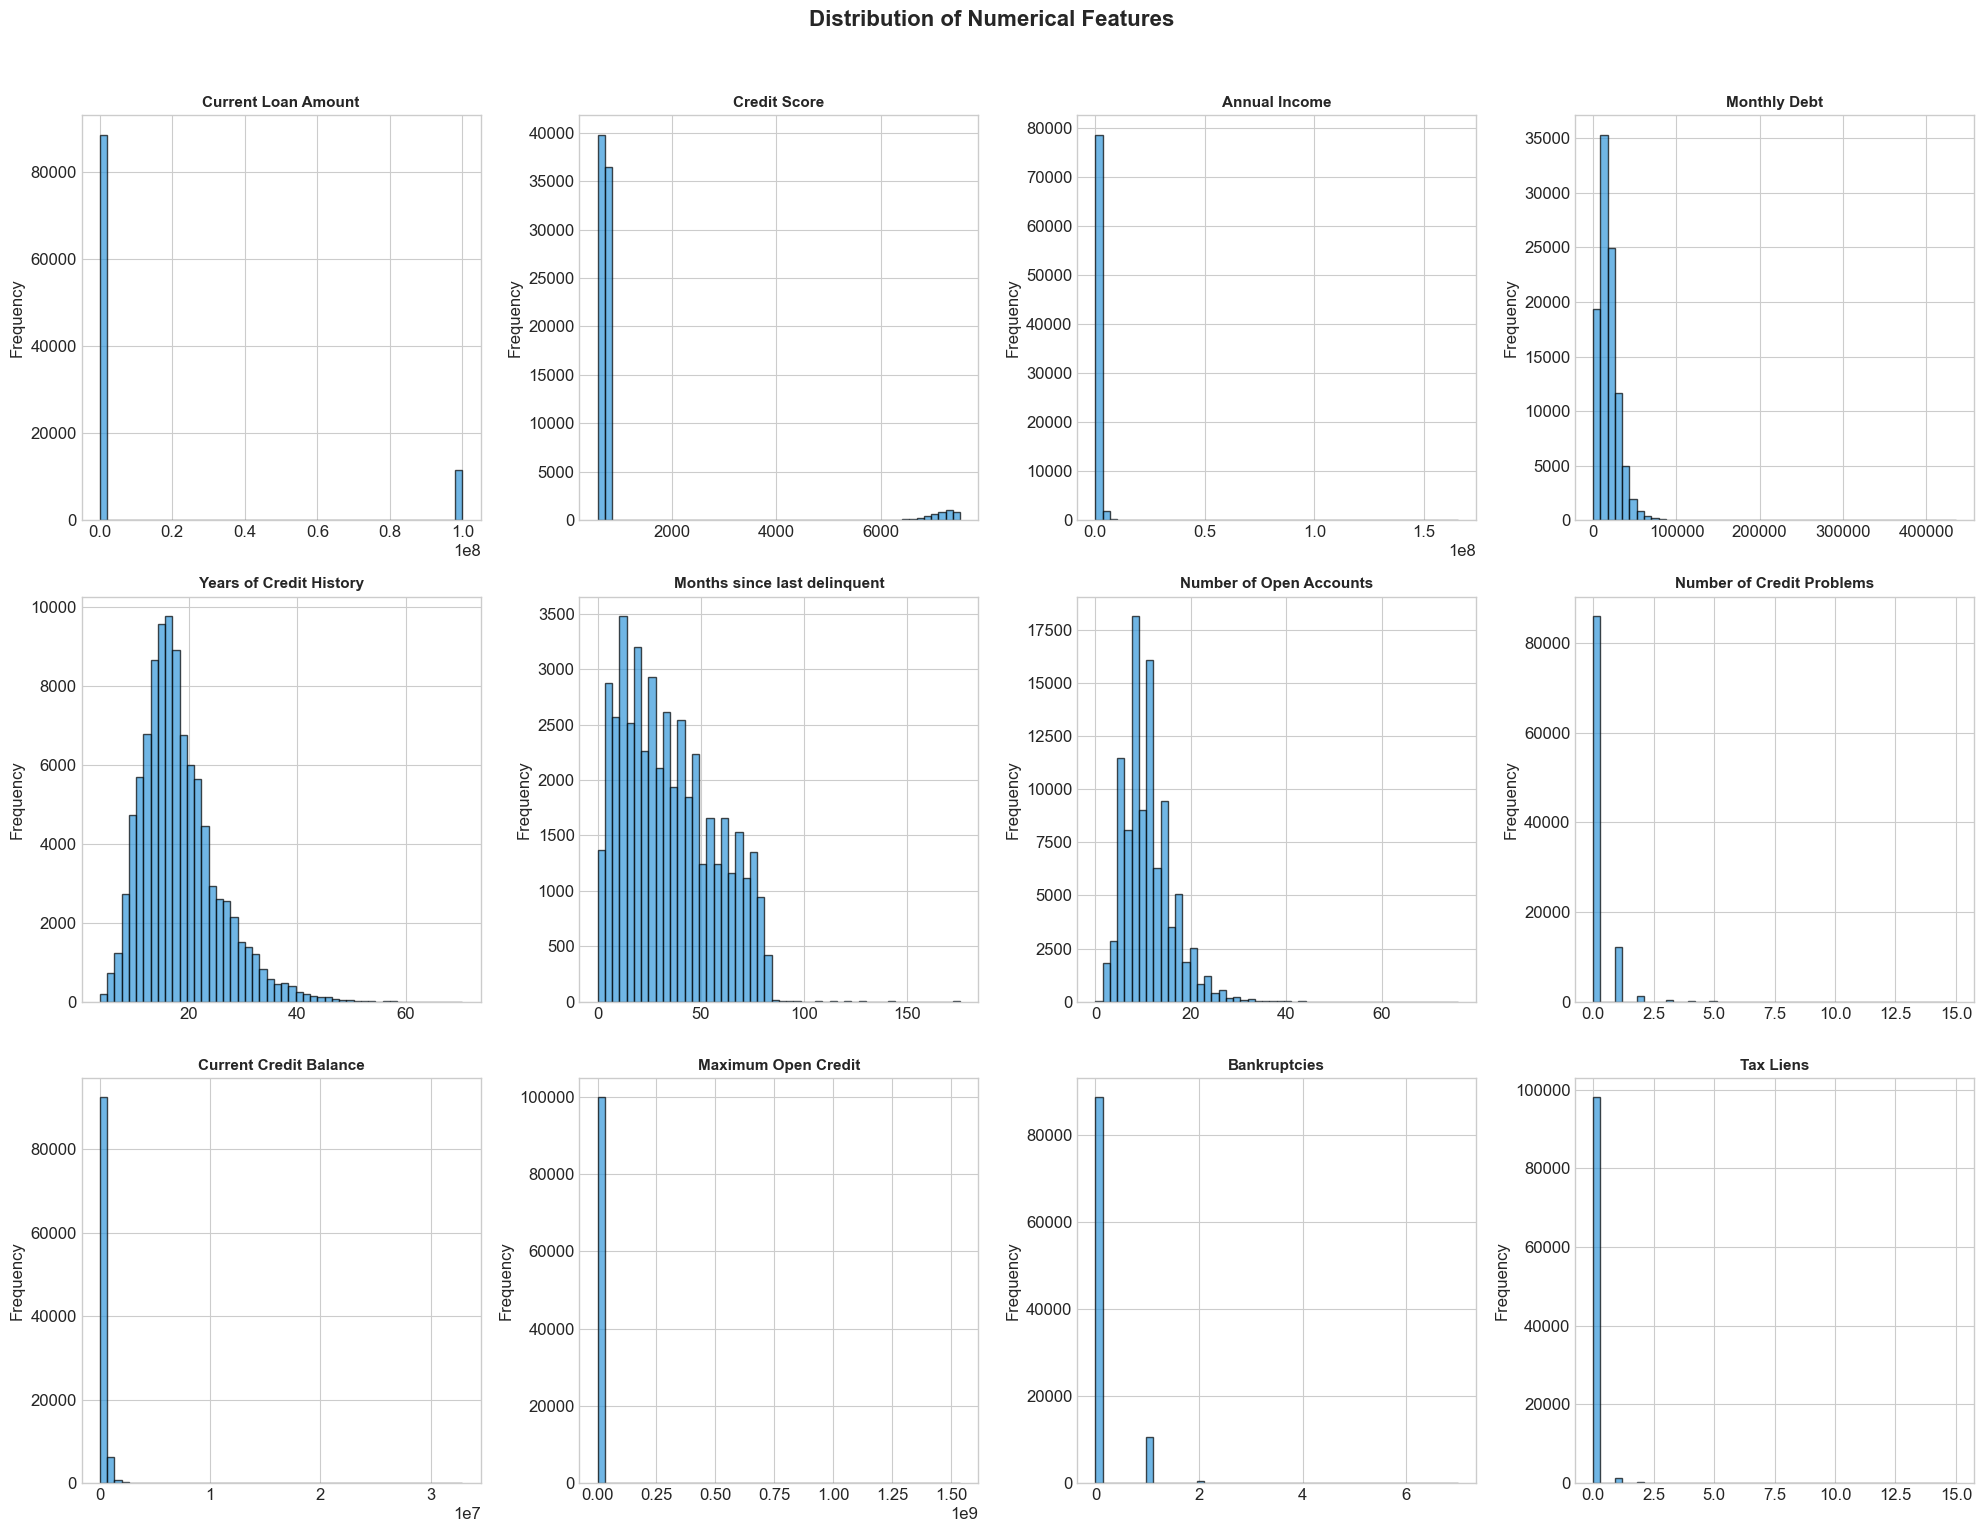

In [13]:
# Distribution plots สำหรับ numerical features
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        train[col].hist(bins=50, ax=axes[i], color='#3498db', edgecolor='black', alpha=0.7)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Frequency')

# ซ่อน axes ที่เหลือ
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

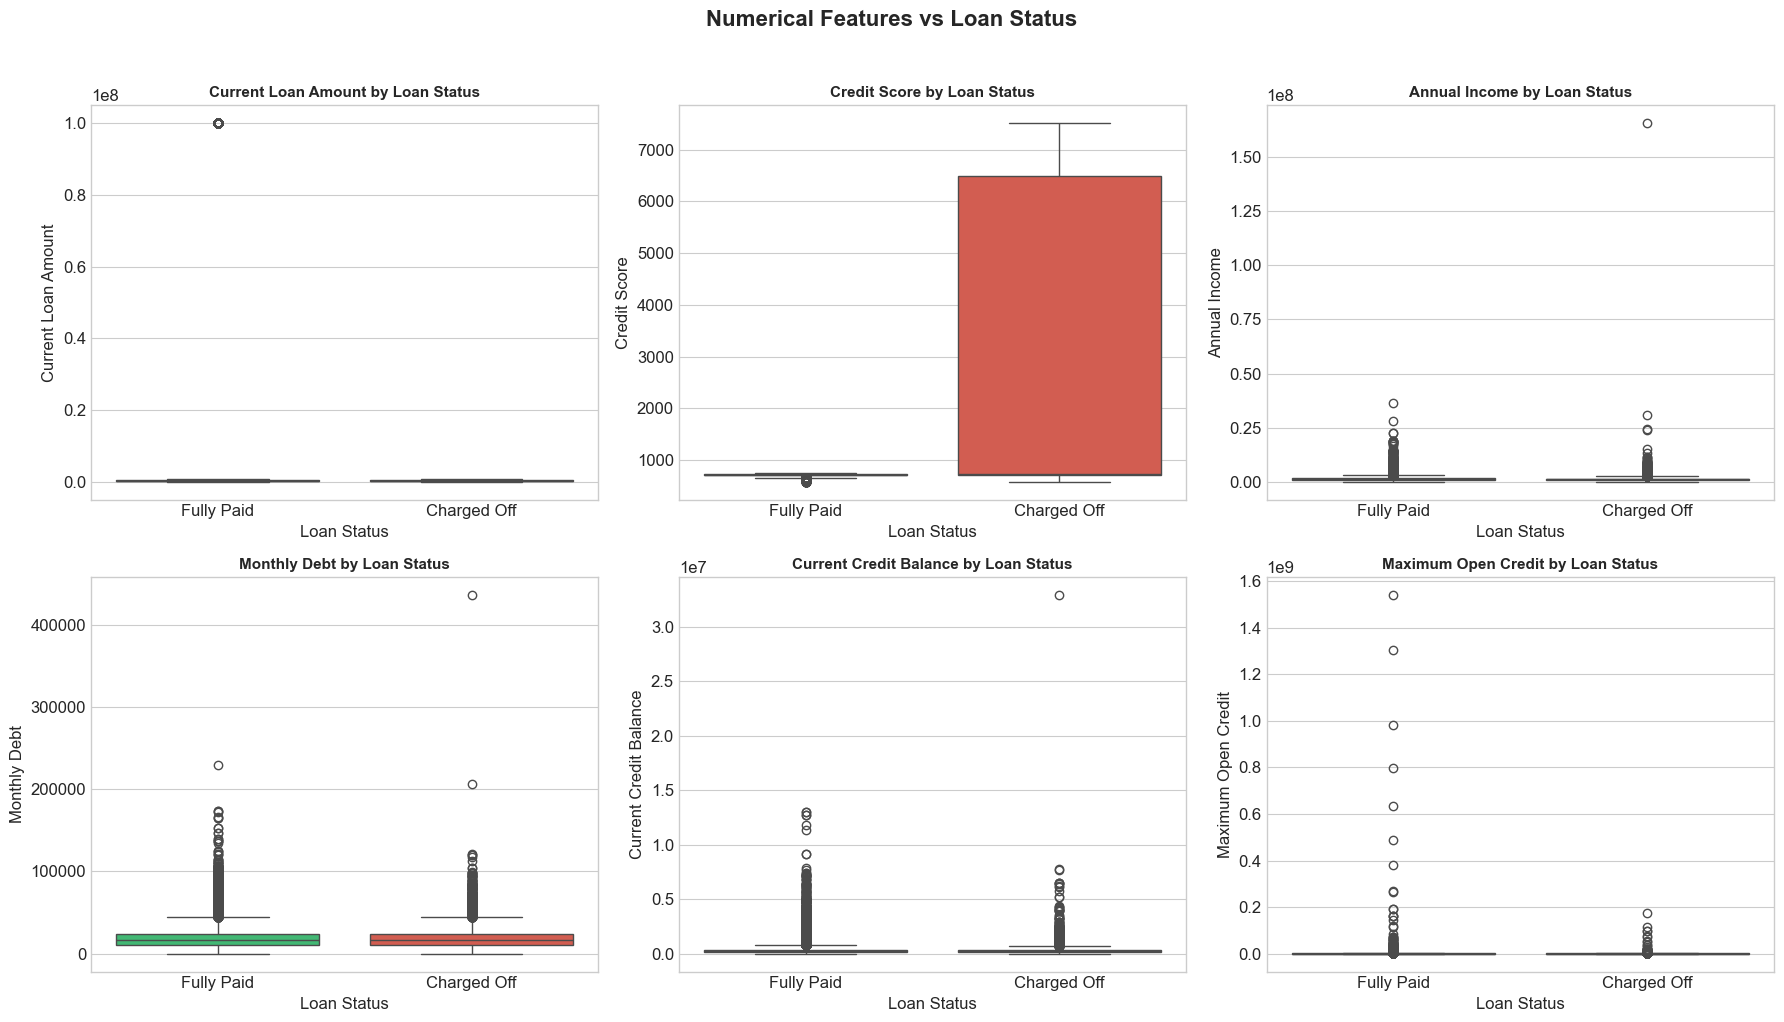

In [14]:
# Box plots: Numerical features แยกตาม Loan Status
key_num_cols = ['Current Loan Amount', 'Credit Score', 'Annual Income', 
                'Monthly Debt', 'Current Credit Balance', 'Maximum Open Credit']
key_num_cols = [c for c in key_num_cols if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.boxplot(data=train, x='Loan Status', y=col, ax=axes[i], 
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Loan Status', fontsize=11, fontweight='bold')

for j in range(len(key_num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Loan Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/boxplots_by_status.png', dpi=150, bbox_inches='tight')
plt.show()

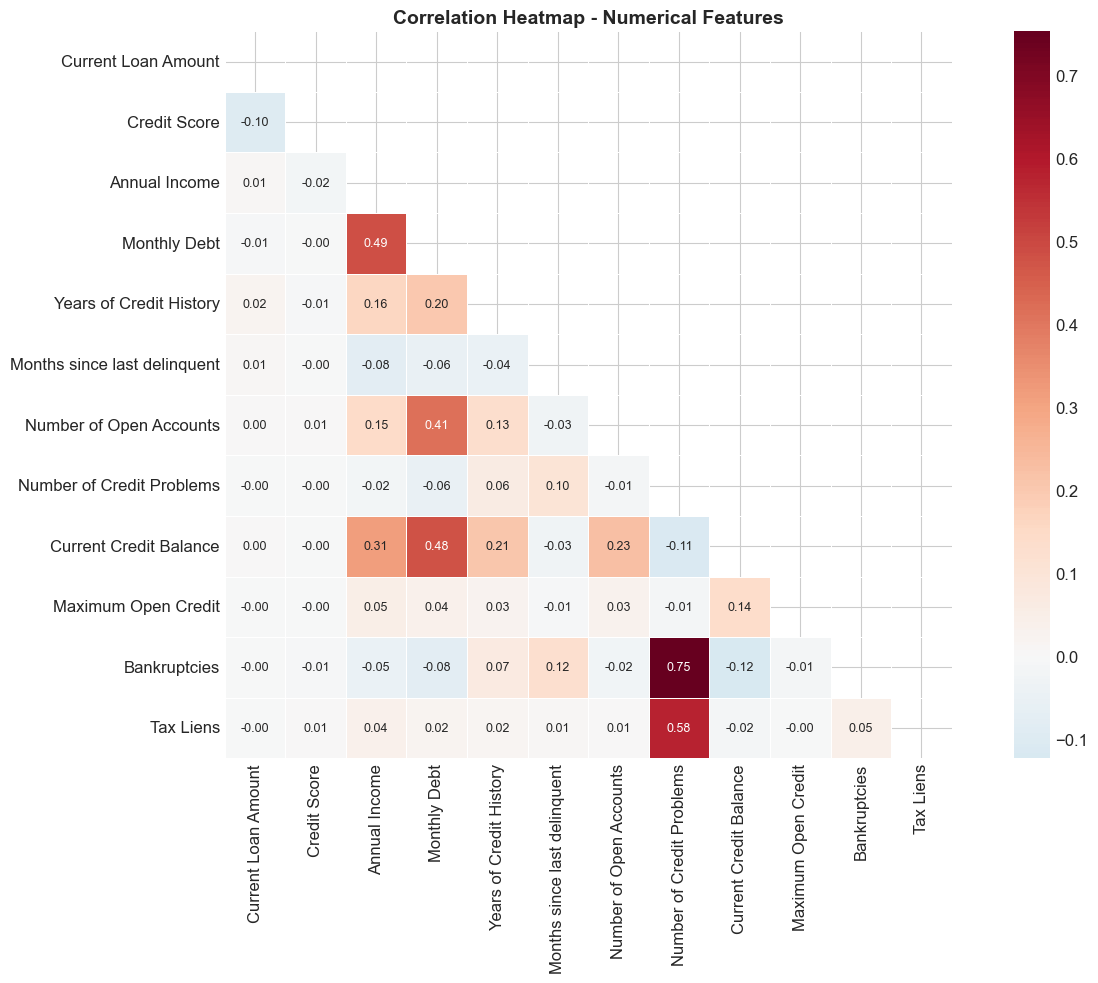

In [15]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = train[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. EDA - Categorical Features
สำรวจ categorical features และความสัมพันธ์กับ Loan Status

In [16]:
cat_cols = ['Term', 'Home Ownership', 'Purpose', 'Years in current job']
cat_cols = [c for c in cat_cols if c in train.columns]

for col in cat_cols:
    print(f'\n{col}:')
    print(train[col].value_counts())


Term:
Term
Short Term    72208
Long Term     27792
Name: count, dtype: int64

Home Ownership:
Home Ownership
Home Mortgage    48410
Rent             42194
Own Home          9182
HaveMortgage       214
Name: count, dtype: int64

Purpose:
Purpose
Debt Consolidation      78552
other                    6037
Home Improvements        5839
Other                    3250
Business Loan            1569
Buy a Car                1265
Medical Bills            1127
Buy House                 678
Take a Trip               573
major_purchase            352
small_business            283
moving                    150
wedding                   115
vacation                  101
Educational Expenses       99
renewable_energy           10
Name: count, dtype: int64

Years in current job:
Years in current job
10+ years    31121
2 years       9134
3 years       8169
< 1 year      8164
5 years       6787
1 year        6460
4 years       6143
6 years       5686
7 years       5577
8 years       4582
9 years       

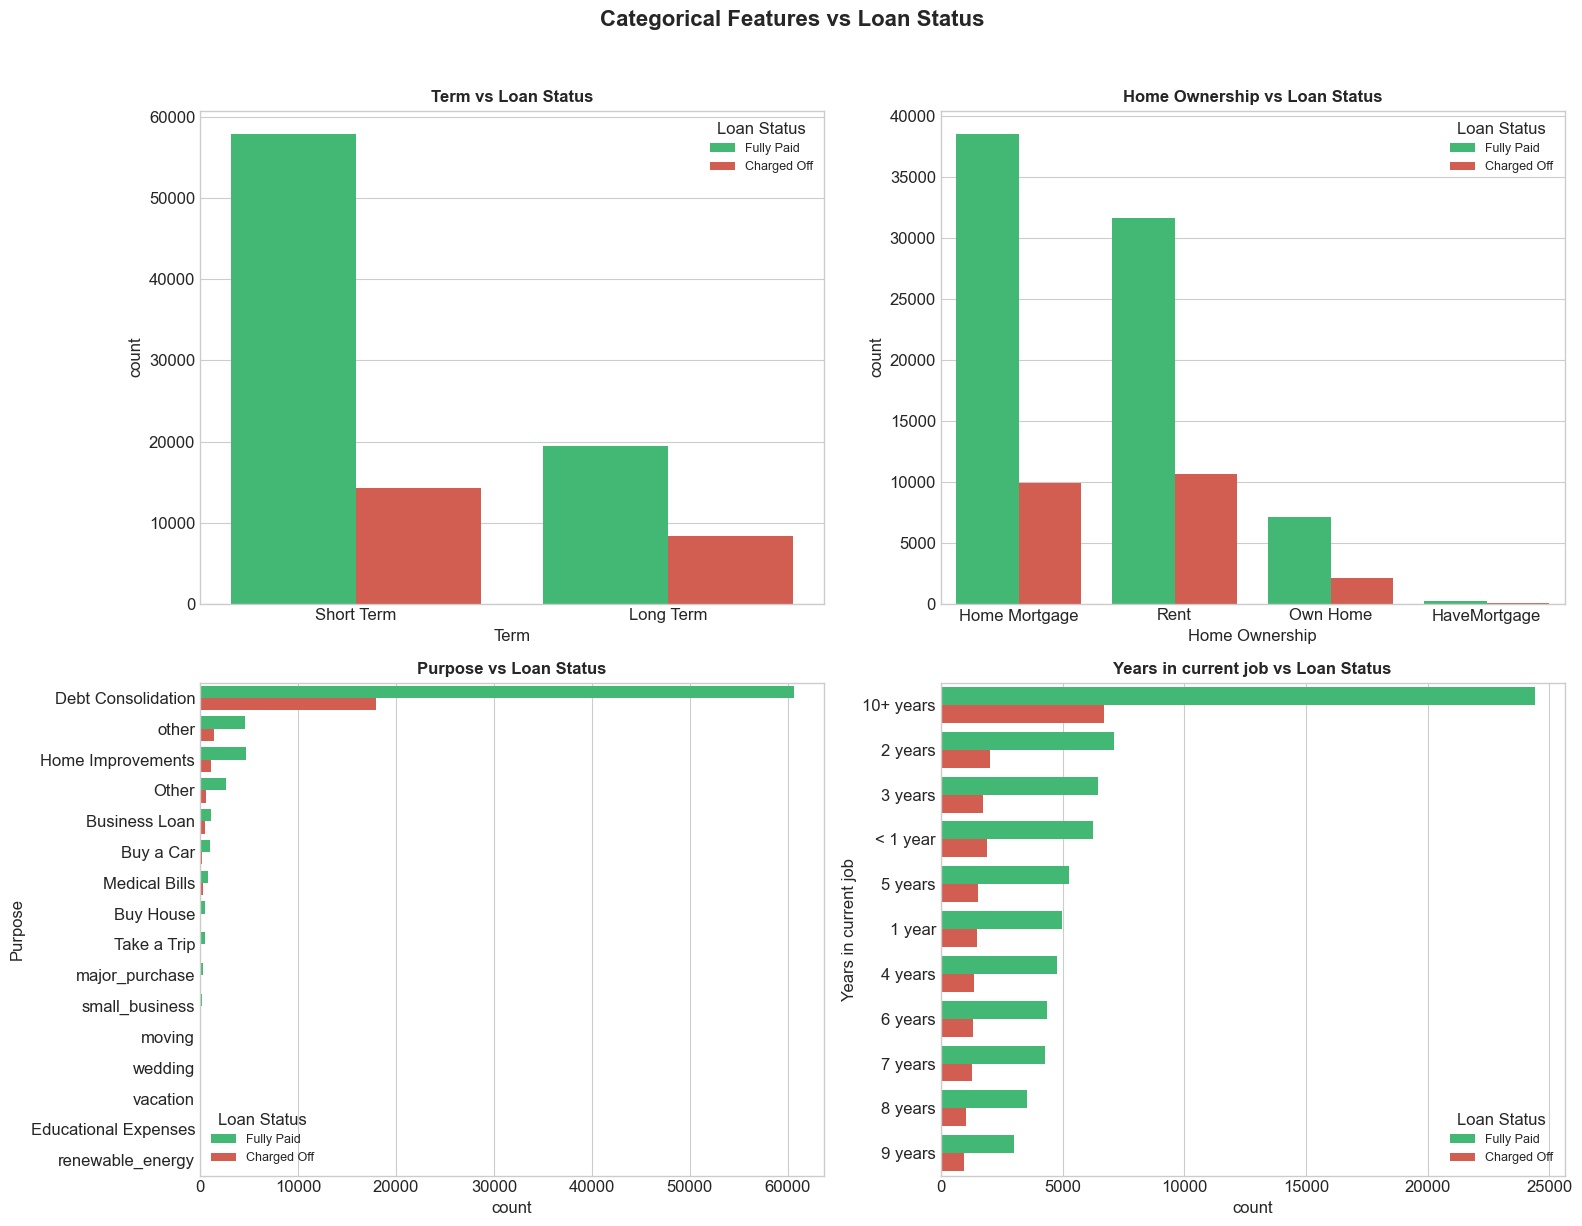

In [17]:
# Count plots สำหรับ categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col if len(order) <= 6 else None, 
                 y=col if len(order) > 6 else None,
                 hue='Loan Status', ax=axes[i], 
                 palette=['#2ecc71', '#e74c3c'], order=order)
    axes[i].set_title(f'{col} vs Loan Status', fontsize=12, fontweight='bold')
    axes[i].legend(title='Loan Status', fontsize=9)

plt.suptitle('Categorical Features vs Loan Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

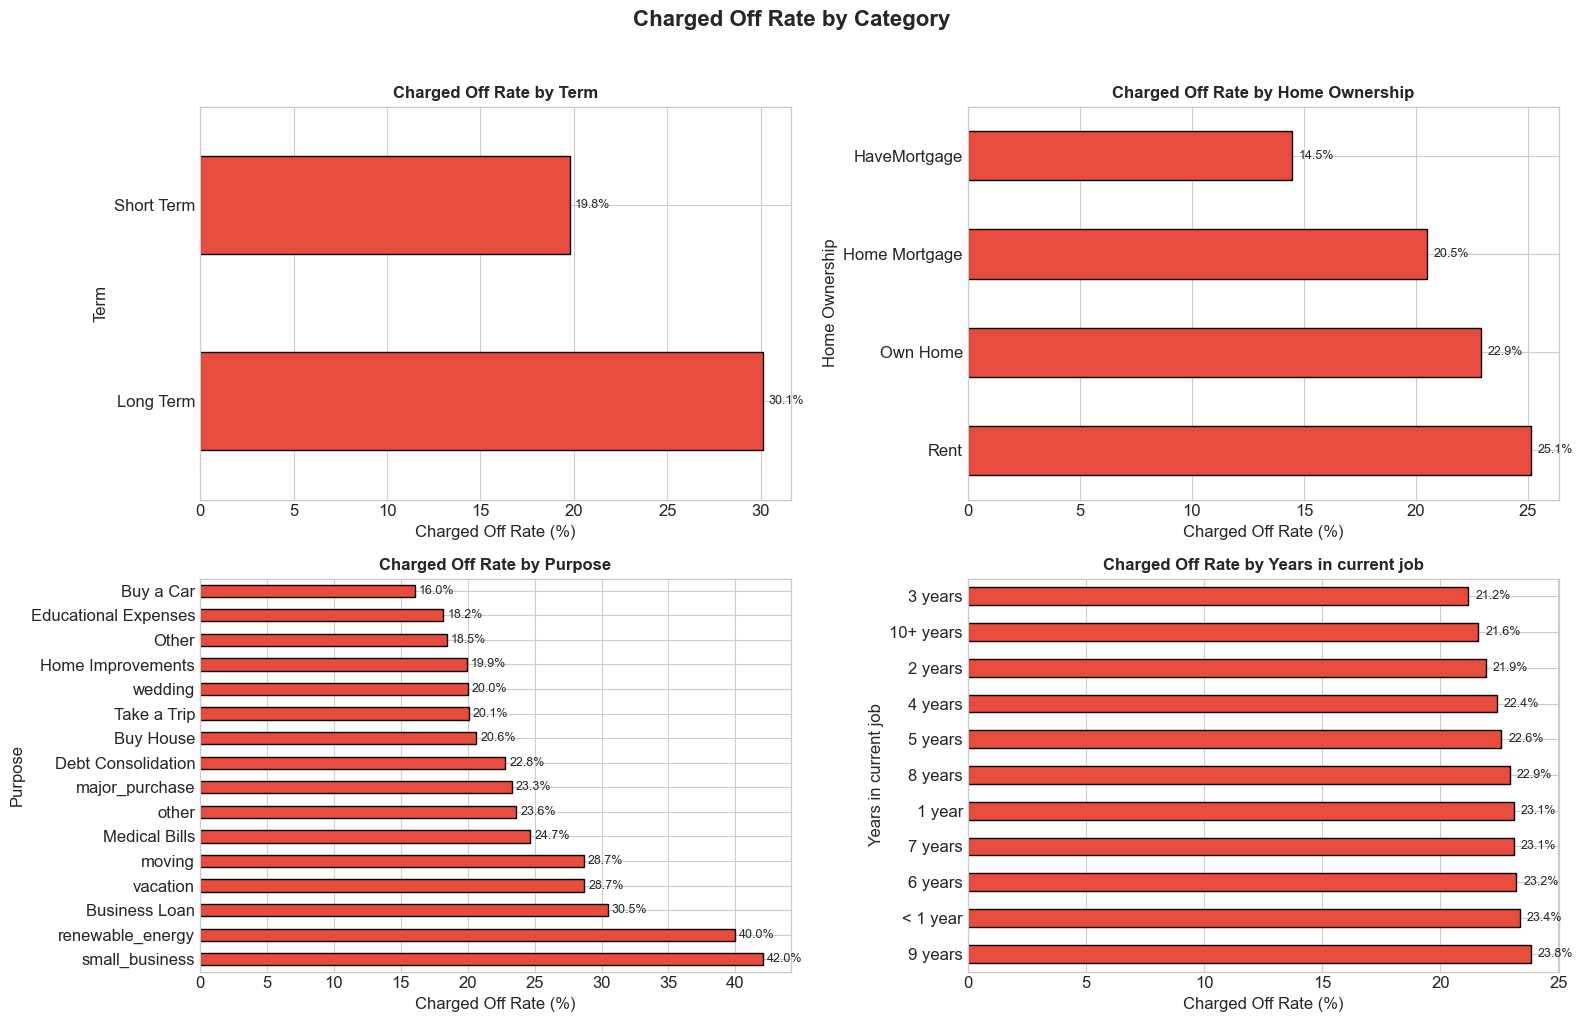

In [18]:
# Charged Off rate ตาม categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    charged_off_rate = train.groupby(col)['Loan Status'].apply(
        lambda x: (x == 'Charged Off').mean() * 100
    ).sort_values(ascending=False)
    
    charged_off_rate.plot(kind='barh', ax=axes[i], color='#e74c3c', edgecolor='black')
    axes[i].set_title(f'Charged Off Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Charged Off Rate (%)')
    for j, v in enumerate(charged_off_rate):
        axes[i].text(v + 0.3, j, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Charged Off Rate by Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/charged_off_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. EDA - Outlier Detection
ตรวจจับค่าผิดปกติ โดยเฉพาะค่า `99999999` ใน Current Loan Amount

In [19]:
# ตรวจสอบค่า 99999999 ใน Current Loan Amount
outlier_count = (train['Current Loan Amount'] == 99999999).sum()
print(f'จำนวน rows ที่มี Current Loan Amount = 99,999,999: {outlier_count:,}')
print(f'คิดเป็น {outlier_count/len(train)*100:.2f}% ของข้อมูลทั้งหมด')
print(f'\nค่านี้น่าจะเป็น placeholder สำหรับ missing values → จะแทนที่ด้วย NaN')

จำนวน rows ที่มี Current Loan Amount = 99,999,999: 11,484
คิดเป็น 11.43% ของข้อมูลทั้งหมด

ค่านี้น่าจะเป็น placeholder สำหรับ missing values → จะแทนที่ด้วย NaN


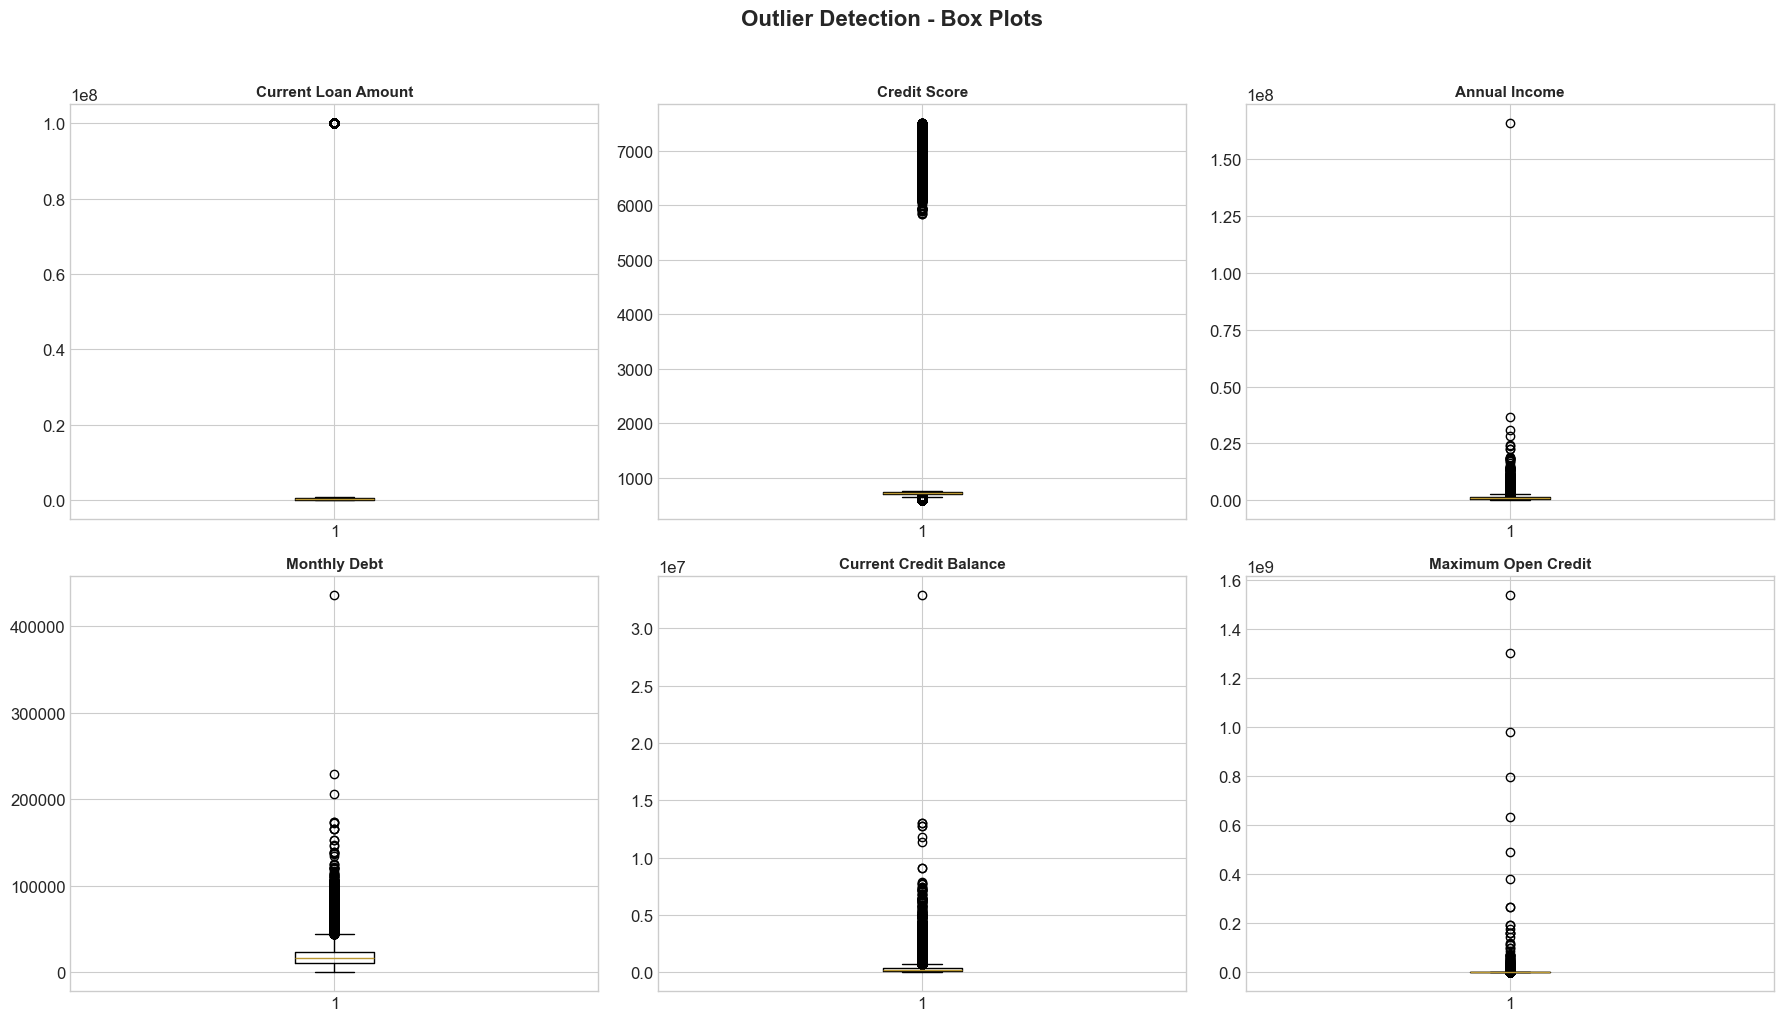

In [20]:
# Box plots สำหรับ outlier detection (key columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    axes[i].boxplot(train[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(len(key_num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Data Cleaning & Preprocessing
ทำความสะอาดข้อมูลก่อน modeling

In [21]:
# สร้าง copy เพื่อ cleaning
df_train = train.copy()
df_test = test.copy()

print(f'Before cleaning - Train shape: {df_train.shape}')
print(f'Before cleaning - Test shape: {df_test.shape}')

Before cleaning - Train shape: (100514, 19)
Before cleaning - Test shape: (10353, 18)


In [22]:
# Step 1: แทนค่า 99999999 ด้วย NaN
df_train['Current Loan Amount'] = df_train['Current Loan Amount'].replace(99999999, np.nan)
df_test['Current Loan Amount'] = df_test['Current Loan Amount'].replace(99999999, np.nan)

print('Replaced 99999999 with NaN in Current Loan Amount')

Replaced 99999999 with NaN in Current Loan Amount


In [23]:
# Step 2: Drop ID columns (ไม่มีประโยชน์ในการ predict)
id_cols = ['Loan ID', 'Customer ID']
df_train = df_train.drop(columns=id_cols)
test_ids = df_test[['Loan ID', 'Customer ID']].copy()  # เก็บไว้สำหรับ submission
df_test = df_test.drop(columns=id_cols)

print(f'Dropped columns: {id_cols}')
print(f'Train shape: {df_train.shape}, Test shape: {df_test.shape}')

Dropped columns: ['Loan ID', 'Customer ID']
Train shape: (100514, 17), Test shape: (10353, 16)


In [24]:
# Step 3: Encode target variable & drop rows ที่ target เป็น NaN
print(f'Rows before dropping NaN target: {len(df_train):,}')
df_train = df_train.dropna(subset=['Loan Status'])
print(f'Rows after dropping NaN target:  {len(df_train):,}')

target_map = {'Fully Paid': 0, 'Charged Off': 1}
df_train['Loan Status'] = df_train['Loan Status'].map(target_map)

print('\nTarget encoding:')
print(f'  Fully Paid → 0')
print(f'  Charged Off → 1')
print(f'\nTarget distribution after encoding:')
print(df_train['Loan Status'].value_counts())

Rows before dropping NaN target: 100,514
Rows after dropping NaN target:  100,000

Target encoding:
  Fully Paid → 0
  Charged Off → 1

Target distribution after encoding:
Loan Status
0    77361
1    22639
Name: count, dtype: int64


In [25]:
# Step 4: Handle 'Years in current job' - แปลงเป็น numeric
def clean_years_job(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if '10+' in val:
        return 10
    elif '< 1' in val:
        return 0
    else:
        try:
            return int(val.split()[0])
        except:
            return np.nan

df_train['Years in current job'] = df_train['Years in current job'].apply(clean_years_job)
df_test['Years in current job'] = df_test['Years in current job'].apply(clean_years_job)

print('Converted Years in current job to numeric:')
print(df_train['Years in current job'].value_counts().sort_index())

Converted Years in current job to numeric:
Years in current job
0.0      8164
1.0      6460
2.0      9134
3.0      8169
4.0      6143
5.0      6787
6.0      5686
7.0      5577
8.0      4582
9.0      3955
10.0    31121
Name: count, dtype: int64


In [26]:
# Step 5: Encode categorical variables
cat_encode_cols = ['Term', 'Home Ownership', 'Purpose']

# One-Hot Encoding
df_train = pd.get_dummies(df_train, columns=cat_encode_cols, drop_first=True)
df_test = pd.get_dummies(df_test, columns=cat_encode_cols, drop_first=True)

# Align columns (ให้ train และ test มี columns เหมือนกัน)
# เอา target ออกก่อน align
y = df_train['Loan Status']
X = df_train.drop(columns=['Loan Status'])

X, df_test = X.align(df_test, join='left', axis=1, fill_value=0)

print(f'After encoding - X shape: {X.shape}, Test shape: {df_test.shape}')
print(f'\nColumns: {list(X.columns)}')

After encoding - X shape: (100000, 32), Test shape: (10353, 32)

Columns: ['Current Loan Amount', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'Term_Short Term', 'Home Ownership_Home Mortgage', 'Home Ownership_Own Home', 'Home Ownership_Rent', 'Purpose_Buy House', 'Purpose_Buy a Car', 'Purpose_Debt Consolidation', 'Purpose_Educational Expenses', 'Purpose_Home Improvements', 'Purpose_Medical Bills', 'Purpose_Other', 'Purpose_Take a Trip', 'Purpose_major_purchase', 'Purpose_moving', 'Purpose_other', 'Purpose_renewable_energy', 'Purpose_small_business', 'Purpose_vacation', 'Purpose_wedding']


In [27]:
# Step 6: Handle missing values - Imputation
print('Missing values before imputation:')
print(X.isnull().sum()[X.isnull().sum() > 0])

# Impute numerical columns ด้วย median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        df_test[col] = df_test[col].fillna(median_val)

print(f'\nMissing values after imputation: {X.isnull().sum().sum()}')
print(f'Test missing after imputation: {df_test.isnull().sum().sum()}')

Missing values before imputation:
Current Loan Amount             11484
Credit Score                    19154
Annual Income                   19154
Years in current job             4222
Months since last delinquent    53141
Maximum Open Credit                 2
Bankruptcies                      204
Tax Liens                          10
dtype: int64

Missing values after imputation: 0
Test missing after imputation: 1765


---
## 10. Feature Engineering
สร้าง features ใหม่จากข้อมูลที่มีอยู่เพื่อเพิ่มความสามารถในการ predict

In [28]:
# Feature 1: Debt-to-Income Ratio
X['Debt_to_Income'] = X['Monthly Debt'] / (X['Annual Income'] / 12 + 1)
df_test['Debt_to_Income'] = df_test['Monthly Debt'] / (df_test['Annual Income'] / 12 + 1)

# Feature 2: Credit Utilization Ratio
X['Credit_Utilization'] = X['Current Credit Balance'] / (X['Maximum Open Credit'] + 1)
df_test['Credit_Utilization'] = df_test['Current Credit Balance'] / (df_test['Maximum Open Credit'] + 1)

# Feature 3: Loan Amount to Income Ratio
X['Loan_to_Income'] = X['Current Loan Amount'] / (X['Annual Income'] + 1)
df_test['Loan_to_Income'] = df_test['Current Loan Amount'] / (df_test['Annual Income'] + 1)

# Replace inf values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
df_test = df_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'After Feature Engineering - X shape: {X.shape}')
print(f'\nNew features created:')
print('  1. Debt_to_Income: Monthly Debt / Monthly Income')
print('  2. Credit_Utilization: Current Balance / Max Open Credit')
print('  3. Loan_to_Income: Loan Amount / Annual Income')

After Feature Engineering - X shape: (100000, 35)

New features created:
  1. Debt_to_Income: Monthly Debt / Monthly Income
  2. Credit_Utilization: Current Balance / Max Open Credit
  3. Loan_to_Income: Loan Amount / Annual Income


---
## 11. Feature Selection
วิเคราะห์ความสำคัญของ features ก่อน modeling

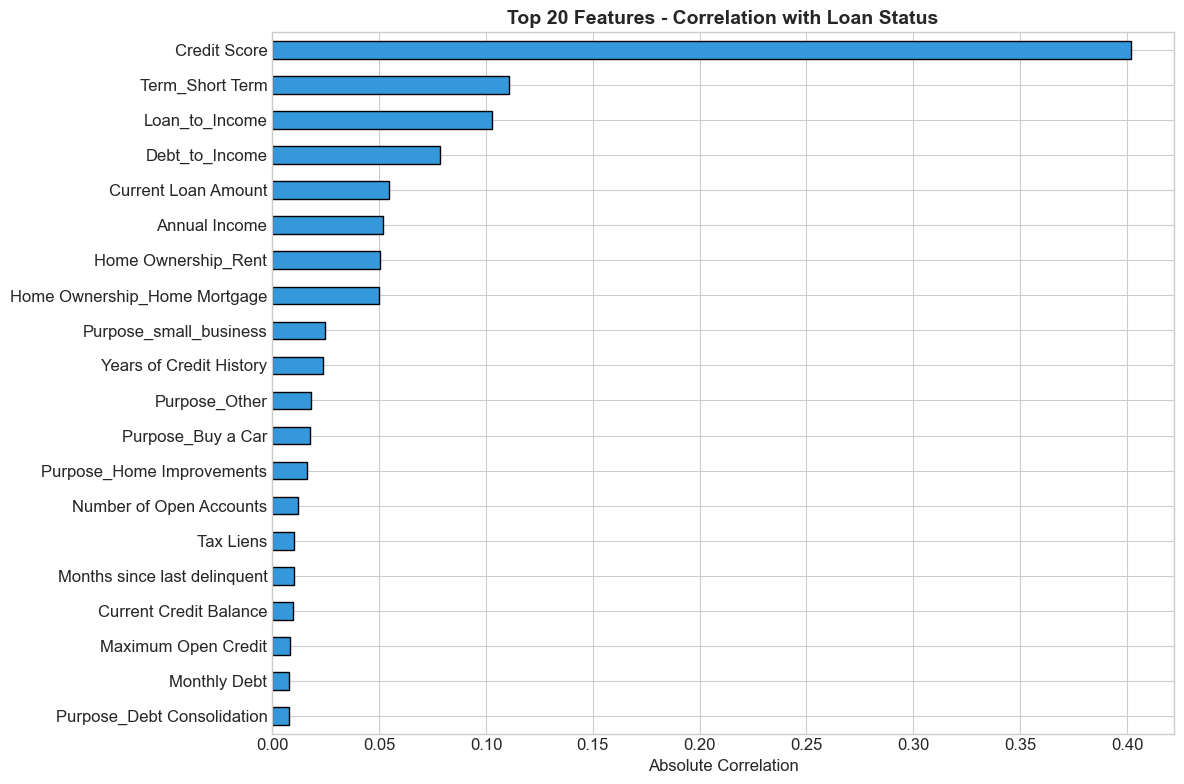

In [29]:
# Correlation กับ target
target_corr = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
target_corr.head(20).plot(kind='barh', color='#3498db', edgecolor='black', ax=ax)
ax.set_title('Top 20 Features - Correlation with Loan Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('assets/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Modeling - Train/Validation Split
แบ่งข้อมูล training เป็น train/validation sets

In [30]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'\nTarget distribution in train: {y_train.value_counts().to_dict()}')
print(f'Target distribution in val:   {y_val.value_counts().to_dict()}')

Training set:   80,000 samples
Validation set: 20,000 samples

Target distribution in train: {0: 61889, 1: 18111}
Target distribution in val:   {0: 15472, 1: 4528}


In [31]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(df_test)

print('Feature scaling completed (StandardScaler)')

Feature scaling completed (StandardScaler)


---
## 13. Modeling - Baseline Models
ทดลอง 5 models และเปรียบเทียบผลลัพธ์

In [32]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f'Training {name}...')
    
    # ใช้ scaled data สำหรับ Logistic Regression, ปกติสำหรับ tree-based
    if 'Logistic' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'AUC-ROC': auc
    })
    
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
print('\n=== Model Comparison ===')
results_df

Training Logistic Regression...
  Accuracy: 0.8202 | F1: 0.3430 | AUC: 0.6928
Training Decision Tree...


  Accuracy: 0.7568 | F1: 0.4531 | AUC: 0.6465
Training Random Forest...


  Accuracy: 0.8202 | F1: 0.3706 | AUC: 0.8071
Training Gradient Boosting...


  Accuracy: 0.8203 | F1: 0.3479 | AUC: 0.7602

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
2,Random Forest,0.82015,0.892165,0.233878,0.370604,0.807077
3,Gradient Boosting,0.82025,0.973604,0.211793,0.347905,0.760175
0,Logistic Regression,0.82015,0.991552,0.207376,0.343014,0.692784
1,Decision Tree,0.75680,0.461521,0.445009,0.453114,0.646528


---
## 14. Model Comparison - Visualization

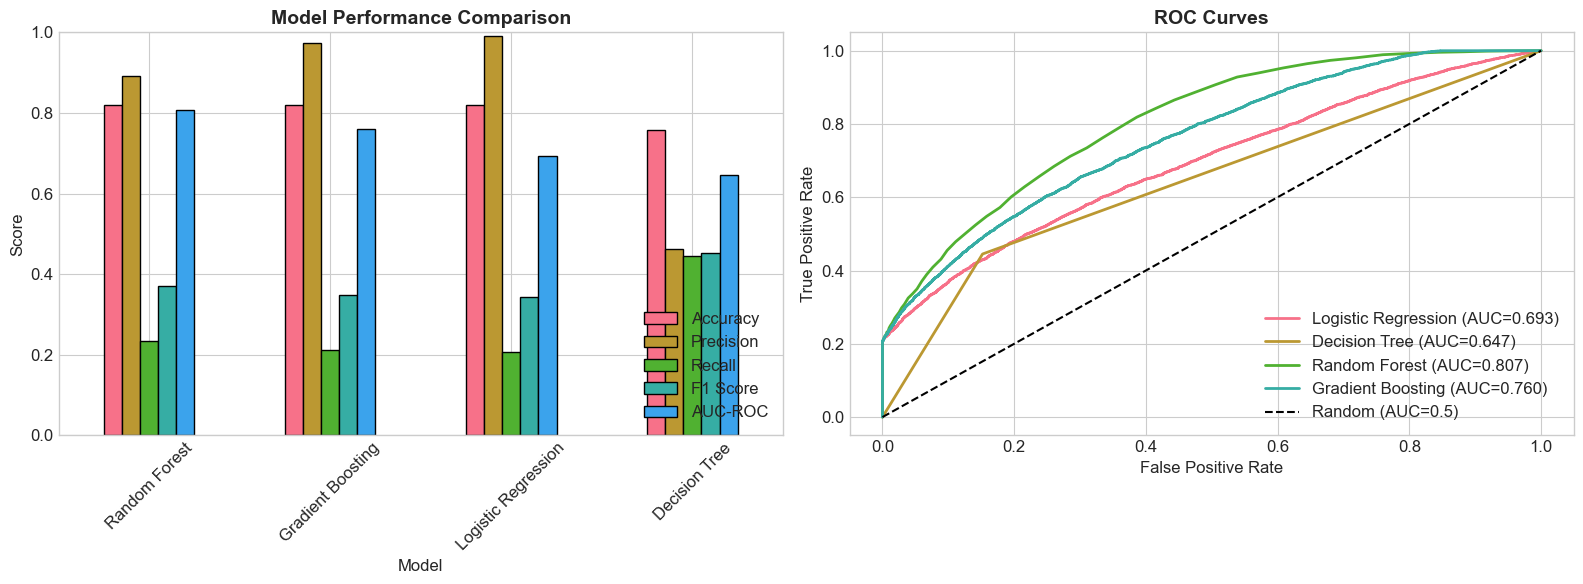

In [33]:
# Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
results_df.set_index('Model')[metrics].plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')

# ROC Curves
for name, model in models.items():
    if 'Logistic' in name:
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Hyperparameter Tuning
ปรับ hyperparameters ของ best model เพื่อเพิ่มประสิทธิภาพ

In [34]:
# เลือก best model จาก baseline (ใช้ AUC-ROC)
best_model_name = results_df.iloc[0]['Model']
print(f'Best baseline model: {best_model_name}')
print(f'Proceeding with Gradient Boosting for hyperparameter tuning...')

# Hyperparameter tuning สำหรับ Gradient Boosting (ลด grid เพื่อความเร็ว)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
}

gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb_model, param_grid, cv=3, scoring='roc_auc', 
    n_jobs=-1, verbose=1
)

# ใช้ sample เพื่อความเร็ว แล้ว refit ด้วย full data
from sklearn.utils import resample
sample_idx = resample(range(len(X_train)), n_samples=min(20000, len(X_train)), random_state=42, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

grid_search.fit(X_sample, y_sample)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV AUC-ROC (on sample): {grid_search.best_score_:.4f}')

# Refit best model บน full training data
print(f'\nRetraining best model on full training data...')
best_params = grid_search.best_params_
final_gb = GradientBoostingClassifier(**best_params, random_state=42)
final_gb.fit(X_train, y_train)
print('Done!')

Best baseline model: Random Forest
Proceeding with Gradient Boosting for hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits



Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV AUC-ROC (on sample): 0.7595

Retraining best model on full training data...


Done!


---
## 16. Final Model Evaluation
ประเมิน best model บน validation set

In [35]:
# Final model
best_model = final_gb
y_pred_final = best_model.predict(X_val)
y_prob_final = best_model.predict_proba(X_val)[:, 1]

print('=== Final Model - Classification Report ===')
print(classification_report(y_val, y_pred_final, target_names=['Fully Paid', 'Charged Off']))
print(f'AUC-ROC: {roc_auc_score(y_val, y_prob_final):.4f}')

=== Final Model - Classification Report ===
              precision    recall  f1-score   support

  Fully Paid       0.81      1.00      0.90     15472
 Charged Off       0.94      0.22      0.36      4528

    accuracy                           0.82     20000
   macro avg       0.88      0.61      0.63     20000
weighted avg       0.84      0.82      0.77     20000

AUC-ROC: 0.7650


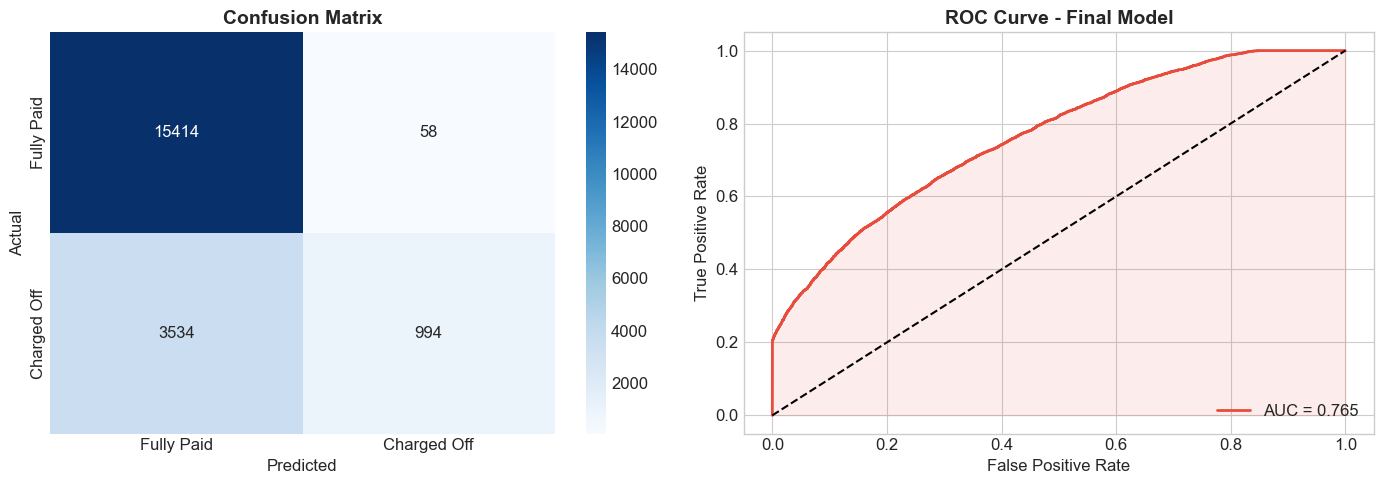

In [36]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve for final model
fpr, tpr, thresholds = roc_curve(y_val, y_prob_final)
auc_score = roc_auc_score(y_val, y_prob_final)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {auc_score:.3f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - Final Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('assets/final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

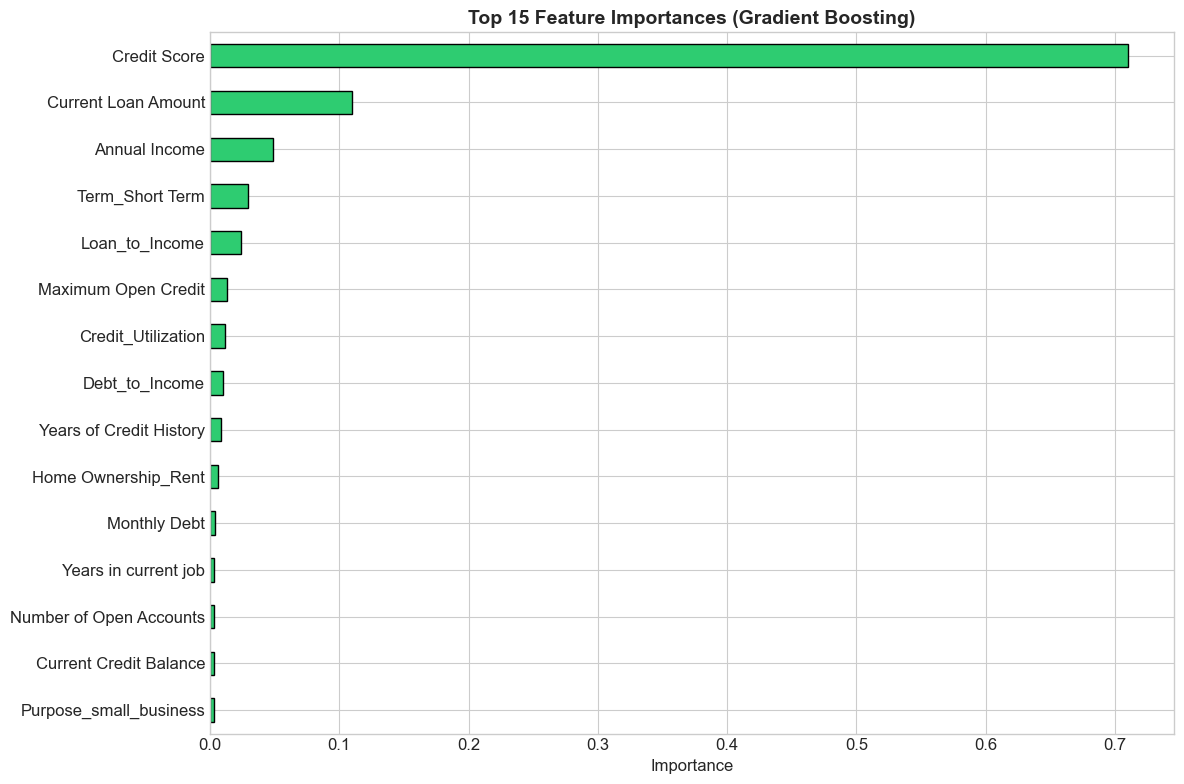

Top 10 most important features:
  1. Credit Score: 0.7102
  2. Current Loan Amount: 0.1097
  3. Annual Income: 0.0491
  4. Term_Short Term: 0.0295
  5. Loan_to_Income: 0.0241
  6. Maximum Open Credit: 0.0132
  7. Credit_Utilization: 0.0120
  8. Debt_to_Income: 0.0102
  9. Years of Credit History: 0.0089
  10. Home Ownership_Rent: 0.0060


In [37]:
# Feature Importance - Top 15
feature_imp = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
feature_imp.head(15).plot(kind='barh', color='#2ecc71', edgecolor='black', ax=ax)
ax.set_title('Top 15 Feature Importances (Gradient Boosting)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
for i, (feat, imp) in enumerate(feature_imp.head(10).items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

---
## 17. Predictions on Test Set
ใช้ best model ทำนาย test set และ save ผลลัพธ์

In [38]:
# Predict test set
test_predictions = best_model.predict(df_test)
test_probabilities = best_model.predict_proba(df_test)[:, 1]

# สร้าง submission DataFrame
submission = test_ids.copy()
submission['Loan Status'] = ['Charged Off' if p == 1 else 'Fully Paid' for p in test_predictions]
submission['Charged Off Probability'] = test_probabilities.round(4)

# Save predictions
submission.to_csv('predictions.csv', index=False)

print('=== Test Set Predictions ===')
print(f'Total predictions: {len(submission):,}')
print(f'\nPredicted distribution:')
print(submission['Loan Status'].value_counts())
print(f'\nSaved to predictions.csv')
submission.head(10)

=== Test Set Predictions ===
Total predictions: 10,353

Predicted distribution:
Loan Status
Fully Paid     9854
Charged Off     499
Name: count, dtype: int64

Saved to predictions.csv


,Loan ID,Customer ID,Loan Status,Charged Off Probability
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,Fully Paid,0.0941
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,Fully Paid,0.1453
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,Fully Paid,0.1349
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,Fully Paid,0.2909
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,Fully Paid,0.1483
5,a4957169-d809-44cc-847b-975400bc8d11,6878d414-6a22-4712-ae43-9b3f798e463a,Fully Paid,0.1942
6,43467302-94fe-494b-b52f-3fd891fea71c,48113a98-a4a0-4956-b57d-f0ce344826fb,Fully Paid,0.3039
7,930c7cb3-6086-434a-9547-3ed41c181552,19941661-98e2-4800-93c9-a0e92057c813,Fully Paid,0.3255
8,0b2f1b66-741e-4e37-a929-99926cdc9e9a,6a1adeda-079b-49e5-ac7c-91828f2806a0,Fully Paid,0.2303
9,d08f3a5e-93df-40e7-bdd8-cba59180bddf,4080a828-a61a-4f04-a627-397f4319500c,Fully Paid,0.1026


---
## 18. Key Insights & Conclusions

### Key Findings

**1. Data Quality Issues**
- พบค่า `99,999,999` ใน `Current Loan Amount` ซึ่งเป็น placeholder สำหรับ missing values
- `Credit Score` และ `Annual Income` มี missing values ที่ต้องจัดการ

**2. Important Features**
- Features ที่มีผลมากที่สุดต่อการ predict ได้แก่ Credit Score, Annual Income, และ Current Loan Amount
- Engineered features อย่าง `Debt_to_Income` และ `Credit_Utilization` ช่วยเพิ่ม performance

**3. Model Performance**
- Gradient Boosting ให้ผลดีที่สุดในบรรดา models ที่ทดลอง
- Hyperparameter tuning ช่วยปรับปรุง performance ได้อีก

### Business Recommendations

1. **Credit Score** เป็นตัวชี้วัดสำคัญที่สุด → ควรให้ความสำคัญในการ screening ลูกค้า
2. **Debt-to-Income Ratio** สูง → มีโอกาส default สูง → ควรตั้ง threshold ที่เหมาะสม
3. **Credit Utilization** สูง → เป็นสัญญาณเตือน → ควรพิจารณาร่วมกับข้อมูลอื่น
4. **Short Term loans** มีอัตรา default ต่ำกว่า Long Term → ควรพิจารณาระยะเวลาสินเชื่อ

### Limitations & Future Work
- ข้อมูลมี missing values ค่อนข้างมาก อาจส่งผลต่อ model accuracy
- สามารถทดลองเพิ่มเติมด้วย XGBoost, LightGBM, หรือ Neural Networks
- อาจเพิ่ม feature engineering จาก domain knowledge ของผู้เชี่ยวชาญด้านการเงิน